<a href="https://colab.research.google.com/github/yorsyd/LearnData/blob/main/Tensorflow_org.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation

## Install and import module

In [1]:
# Install the most re version of TensorFlow to use the improved
# masking support for `tf.keras.layers.MultiHeadAttention`.
# !apt install --allow-change-held-packages libcudnn8=8.1.0.77-1+cuda11.2
# !pip uninstall -y -q tensorflow keras tensorflow-estimator tensorflow-text
# !pip install protobuf~=3.20.3
# !pip install -q tensorflow_datasets
# !pip install -q -U tensorflow-text tensorflow

In [6]:
import logging
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow_datasets as tfds
import tensorflow as tf

import tensorflow_text

## path data

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
path = f'/content/drive/MyDrive/skripsi/Yoga Rusydi Arifin/PROGRAM/Dummy/korpus.csv'

In [7]:
df = pd.read_csv(path)
df.head()

,Unnamed: 0,id,bkl
0,0,Bunga dihalaman rumah dibersihkan semua oleh t...,Bungo dilaman rumah di babat galo dekek tukang...
1,1,Bapak ini sangat suka dengan sayur perut sapi,Gaek lanang iko suko nian gulai sapi babat
2,2,Dia menikahkan anak nya sangat besar-besaran,Nyo nikahi anak nyo berarat-arat nian
3,3,Sakitnya sekarang sudah bertambah parah,Sakitnyo kini lah bertambah arat
4,4,Sudah sebesar ini saya belum juga menghapal pe...,La segedang iko ambo belum jugo apal perkalian


# Preprocessing

In [59]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization

def clean_text(text):
    """Bersihkan teks dari karakter aneh, spasi berlebih, dan lowercase."""
    text = text.lower().strip()
    text = re.sub(r"[^a-zA-Zà-žÀ-Ž0-9\s']", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def clean_data(df, source_col, target_col):
    """Bersihkan teks dan tambahkan token <sos> dan <eos> untuk target."""
    df = df[[source_col, target_col]].dropna().drop_duplicates()
    df[source_col] = df[source_col].apply(clean_text)
    df[target_col] = df[target_col].apply(clean_text)

    # Tambahkan <sos> dan <eos> pada target
    df[target_col] = df[target_col].apply(lambda x: '<sos> ' + x + ' <eos>')
    return df

def split_data(df, source_col, target_col, test_size=0.1):
    """Pisahkan data menjadi train dan validasi."""
    return train_test_split(
        df[source_col], df[target_col], test_size=test_size, random_state=42
    )

def create_vectorizers(train_src, train_tgt, max_tokens=10000, src_seq_len=40, tgt_seq_len=42):
    """Buat TextVectorization untuk input dan target."""
    source_vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=src_seq_len
    )
    target_vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=tgt_seq_len
    )

    source_vectorizer.adapt(train_src)
    target_vectorizer.adapt(train_tgt)
    return source_vectorizer, target_vectorizer

def format_dataset(src, tgt, source_vectorizer, target_vectorizer):
    """Tokenisasi dan format input–target untuk model Transformer."""
    src_vectorized = source_vectorizer(src)
    tgt_vectorized = target_vectorizer(tgt)

    encoder_input = src_vectorized
    decoder_input = tgt_vectorized[:, :-1]
    target_labels = tgt_vectorized[:, 1:]

    return (encoder_input, decoder_input), target_labels

def make_dataset(src_texts, tgt_texts, source_vectorizer, target_vectorizer, batch_size=64):
    """Buat tf.data.Dataset untuk pelatihan."""
    dataset = tf.data.Dataset.from_tensor_slices((src_texts, tgt_texts))
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(
        lambda src, tgt: format_dataset(src, tgt, source_vectorizer, target_vectorizer),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        lambda inputs, targets: ({'encoder_input': inputs[0], 'decoder_input': inputs[1]}, targets),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return dataset.prefetch(tf.data.AUTOTUNE)

def prepare_datasets(
    df,
    source_col="banjar",
    target_col="indonesia",
    max_tokens=10000,
    src_seq_len=40,
    tgt_seq_len=42,
    batch_size=64,
    test_size=0.1
):
    """Fungsi utama untuk persiapan data."""
    df = clean_data(df, source_col, target_col)
    train_src, val_src, train_tgt, val_tgt = split_data(df, source_col, target_col, test_size)

    source_vectorizer, target_vectorizer = create_vectorizers(train_src, train_tgt, max_tokens, src_seq_len, tgt_seq_len)

    train_ds = make_dataset(train_src, train_tgt, source_vectorizer, target_vectorizer, batch_size)
    val_ds = make_dataset(val_src, val_tgt, source_vectorizer, target_vectorizer, batch_size)

    return train_ds, val_ds, source_vectorizer, target_vectorizer, train_src, val_src, train_tgt, val_tgt

In [60]:
# Misalnya CSV kamu punya kolom "source" dan "target"
train_ds, val_ds, source_vectorizer, target_vectorizer, train_src, val_src, train_tgt, val_tgt = prepare_datasets(
    df,
    source_col="id",
    target_col="bkl",
    max_tokens=8000,
    src_seq_len=40,
    tgt_seq_len=42,
    batch_size=64,
    test_size=0.1
)

# Define the components

## The embedding and positional encoding layer

In [11]:
def positional_encoding(length, depth):
  depth = depth/2

  positions = np.arange(length)[:, np.newaxis]     # (seq, 1)
  depths = np.arange(depth)[np.newaxis, :]/depth   # (1, depth)

  angle_rates = 1 / (10000**depths)         # (1, depth)
  angle_rads = positions * angle_rates      # (pos, depth)

  pos_encoding = np.concatenate(
      [np.sin(angle_rads), np.cos(angle_rads)],
      axis=-1)

  return tf.cast(pos_encoding, dtype=tf.float32)

In [12]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = positional_encoding(length=2048, depth=d_model)

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    length = tf.shape(x)[1]
    x = self.embedding(x)
    # This factor sets the relative scale of the embedding and positonal_encoding.
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x = x + self.pos_encoding[tf.newaxis, :length, :]
    return x

## Add and normalize + The base attention layer

In [13]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

## The cross attention layer

In [14]:
class CrossAttention(BaseAttention):
  def call(self, x, context):
    attn_output, attn_scores = self.mha(
        query=x,
        key=context,
        value=context,
        return_attention_scores=True)

    # Cache the attention scores for plotting later.
    self.last_attn_scores = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

## The global self-attention layer

In [15]:
class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

## The causal self-attention layer

In [16]:
class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask = True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

## The feed forward network

In [17]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    x = self.add([x, self.seq(x)])
    x = self.layer_norm(x)
    return x

## The encoder layer

In [18]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self,*, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x):
    x = self.self_attention(x)
    x = self.ffn(x)
    return x

## The encoder

In [19]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads,
               dff, vocab_size, dropout_rate=0.1):
    super().__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(
        vocab_size=vocab_size, d_model=d_model)

    self.enc_layers = [
        EncoderLayer(d_model=d_model,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, x):
    # `x` is token-IDs shape: (batch, seq_len)
    x = self.pos_embedding(x)  # Shape `(batch_size, seq_len, d_model)`.

    # Add dropout.
    x = self.dropout(x)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x)

    return x  # Shape `(batch_size, seq_len, d_model)`.

## The decoder layer

In [20]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               d_model,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x, context):
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)

    # Cache the last attention scores for plotting later
    self.last_attn_scores = self.cross_attention.last_attn_scores

    x = self.ffn(x)  # Shape `(batch_size, seq_len, d_model)`.
    return x

## The decoder

In [21]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(d_model=d_model, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    self.last_attn_scores = None

  def call(self, x, context):
    # `x` is token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # The shape of x is (batch_size, target_seq_len, d_model).
    return x

# The Transformer

In [22]:
class Transformer(tf.keras.Model):
  def __init__(self, *, num_layers, d_model, num_heads, dff,
               input_vocab_size, target_vocab_size, dropout_rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=input_vocab_size,
                           dropout_rate=dropout_rate)

    self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=target_vocab_size,
                           dropout_rate=dropout_rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  # Accept inputs as a dictionary
  def call(self, inputs):
    context = inputs['encoder_input'] # Unpack the dictionary here
    x  = inputs['decoder_input']     # Unpack the dictionary here

    context = self.encoder(context)  # (batch_size, context_len, d_model)

    x = self.decoder(x, context)  # (batch_size, target_len, d_model)

    # Final linear layer output.
    logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

    try:
      # Drop the keras mask, so it doesn't scale the losses/metrics.
      # b/250038731
      del logits._keras_mask
    except AttributeError:
      pass

    # Return the final output (logits)
    return logits

## Hyperparameters


In [23]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8
dropout_rate = 0.1

## Make model

In [24]:
transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=len(source_vectorizer.get_vocabulary()),
    target_vocab_size=len(target_vectorizer.get_vocabulary()),
    dropout_rate=dropout_rate)

In [25]:
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Training

## Set up the optimizer

In [26]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [27]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

## Set up the loss and metrics

In [28]:
def masked_loss(label, pred):
  mask = label != 0
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')
  loss = loss_object(label, pred)

  mask = tf.cast(mask, dtype=loss.dtype)
  loss *= mask

  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss


def masked_accuracy(label, pred):
  pred = tf.argmax(pred, axis=2)
  label = tf.cast(label, pred.dtype)
  match = label == pred

  mask = label != 0

  match = match & mask

  match = tf.cast(match, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  return tf.reduce_sum(match)/tf.reduce_sum(mask)

## Train the model

In [29]:
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy])

In [30]:
transformer.fit(train_ds,
                epochs=1,
                validation_data=val_ds)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.


74/74 ━━━━━━━━━━━━━━━━━━━━ 443s 5s/step - loss: 7.9658 - masked_accuracy: 0.0347 - val_loss: 7.4740 - val_masked_accuracy: 0.1565


# Run inference

In [35]:
MAX_TOKENS = 42

class Translator(tf.Module):
  # Modified to accept source_vectorizer and target_vectorizer
  def __init__(self, source_vectorizer, target_vectorizer, transformer):
    self.source_vectorizer = source_vectorizer
    self.target_vectorizer = target_vectorizer
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    # Use the source_vectorizer for input
    # The sentence needs to be a string or list of strings for vectorizer
    sentence = self.source_vectorizer(sentence) # Vectorizer takes string input and returns token IDs

    encoder_input = sentence

    # As the output language is English, initialize the output with the
    # English `[START]` token.
    # Assuming '<sos>' is the start token in target_vectorizer vocabulary
    start_token_id = tf.argmax(self.target_vectorizer(['<sos>'])[0]).numpy() # Get ID of '<sos>'
    start = tf.constant(start_token_id, dtype=tf.int64)[tf.newaxis] # Shape (1,) -> (1,1)

    # Assuming '<eos>' is the end token in target_vectorizer vocabulary
    end_token_id = tf.argmax(self.target_vectorizer(['<eos>'])[0]).numpy() # Get ID of '<eos>'
    end = tf.constant(end_token_id, dtype=tf.int64)[tf.newaxis] # Shape (1,) -> (1,1)


    # `tf.TensorArray` is required here (instead of a Python list), so that the
    # dynamic-loop can be traced by `tf.function`.
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      output = tf.transpose(output_array.stack()) # Shape (1, current_seq_len)
      # Ensure the inputs to the transformer are dictionaries
      predictions = self.transformer({'encoder_input': encoder_input, 'decoder_input': output}, training=False)

      # Select the last token from the `seq_len` dimension.
      predictions = predictions[:, -1:, :]  # Shape `(batch_size, 1, vocab_size)`.

      predicted_id = tf.argmax(predictions, axis=-1, output_type=tf.int64) # Ensure predicted_id is int64

      # Concatenate the `predicted_id` to the output which is given to the
      # decoder as its input.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack()) # Shape (1, tokens)
    # Use the target_vectorizer to detokenize
    # Detokenization requires mapping IDs back to strings.
    # The TextVectorization layer doesn't have a direct 'detokenize' method
    # in the same way tensorflow_text might. We need to manually map.
    # Get the vocabulary
    vocab = self.target_vectorizer.get_vocabulary()
    # Map token IDs to strings, excluding the padding token (usually 0)
    decoded_tokens = [vocab[token_id] for token_id in output[0].numpy() if token_id != 0]

    # Join the tokens to form the text
    # Remove the start and end tokens from the final output string
    text = ' '.join(decoded_tokens)
    if text.startswith('<sos> '):
        text = text[len('<sos> '):]
    if text.endswith(' <eos>'):
        text = text[:-len(' <eos>')]


    # The output tokens for plotting might need to include start/end if desired
    # This part is a bit ambiguous based on the original code's intent for 'tokens'
    # Let's return the raw token IDs array for now.
    tokens = output

    # `tf.function` prevents us from using the attention_weights that were
    # calculated on the last iteration of the loop.
    # So, recalculate them outside the loop.
    # Need to pass inputs as a dictionary here too
    self.transformer({'encoder_input': encoder_input, 'decoder_input': output[:,:-1]}, training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights


In [37]:
translator = Translator(source_vectorizer, target_vectorizer, transformer)

In [50]:
# Modify the print_translation function
def print_translation(sentence, translated_text, ground_truth):
  """Prints the input sentence, translated text, and ground truth."""
  print(f'{"Input:":15s}: {sentence}')
  print(f'{"Prediction":15s}: {translated_text}') # Use translated_text directly
  print(f'{"Ground truth":15s}: {ground_truth}')

# Create attention plots

In [44]:
def plot_attention_head(in_tokens, translated_tokens, attention):
  # The model didn't generate `<START>` in the output. Skip it.
  # Check if translated_tokens is a tensor and has more than one element before slicing
  if tf.is_tensor(translated_tokens) and tf.shape(translated_tokens)[1] > 1:
      # Assuming translated_tokens are token IDs
      # You need to get the string representation for plotting
      # translated_tokens[0] is the batch dimension
      target_vocab = target_vectorizer.get_vocabulary() # Access the target vectorizer from the outer scope
      translated_token_strings = [target_vocab[token_id] for token_id in translated_tokens[0, 1:].numpy()]
  else:
      # Handle cases where translated_tokens might be empty or just the start token
      translated_token_strings = []


  ax = plt.gca()
  ax.matshow(attention)
  # Use the number of tokens (strings) for xticks and yticks
  ax.set_xticks(range(len(in_tokens)))
  ax.set_yticks(range(len(translated_token_strings)))

  # Assuming in_tokens are already strings or can be converted to strings
  ax.set_xticklabels(in_tokens, rotation=90)
  ax.set_yticklabels(translated_token_strings)

In [45]:
# Pass the source_vectorizer to the plot_attention_weights function
def plot_attention_weights(sentence, translated_tokens, attention_heads, source_vectorizer, target_vectorizer):
  # Use the source_vectorizer to convert the input sentence (string) to token IDs
  # Then get the vocabulary from the source_vectorizer to get the string tokens for plotting
  input_token_ids = source_vectorizer([sentence]) # Gives shape (1, seq_len)
  source_vocab = source_vectorizer.get_vocabulary() # Access the source vectorizer from the outer scope
  # Map token IDs back to strings for plotting, excluding padding (usually 0)
  # input_token_ids[0] is the batch dimension
  in_tokens = [source_vocab[token_id] for token_id in input_token_ids[0].numpy() if token_id != 0]


  fig = plt.figure(figsize=(16, 8))

  for h, head in enumerate(attention_heads):
    ax = fig.add_subplot(2, 4, h+1)

    # Pass the string tokens for input and the token IDs for translated to plot_attention_head
    plot_attention_head(in_tokens, translated_tokens, head)

    ax.set_xlabel(f'Head {h+1}')

  plt.tight_layout()
  plt.show()

In [42]:
sentence = df.loc[0, 'id']
ground_truth = df.loc[0, 'bkl']

translated_text, translated_tokens, attention_weights = translator(tf.constant(sentence))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

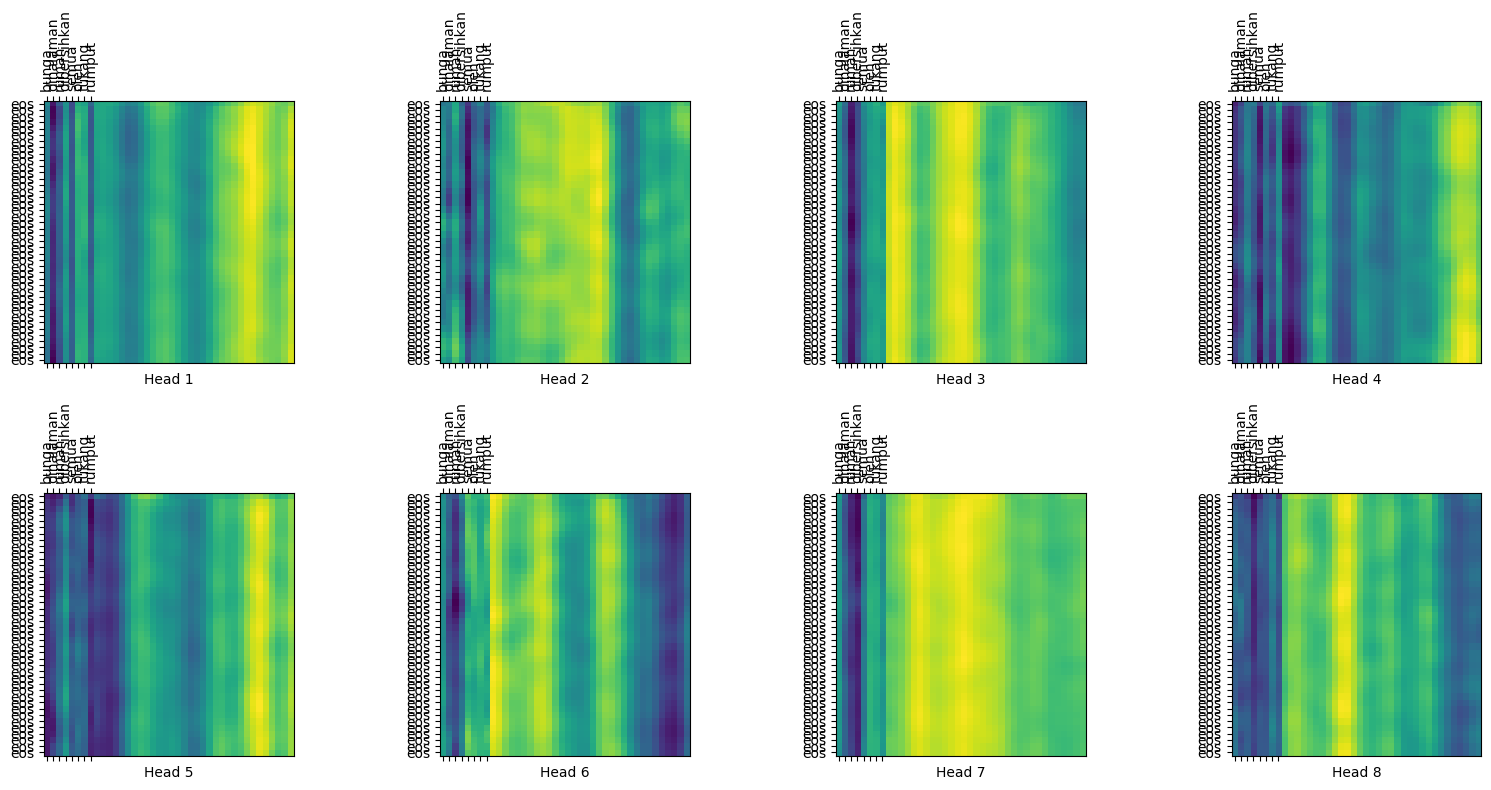

In [46]:
plot_attention_weights(sentence,
                       translated_tokens, # Pass the translated token IDs
                       attention_weights[0], # Pass the attention weights for the first example
                       source_vectorizer, # Pass the source vectorizer
                       target_vectorizer # Pass the target vectorizer
                       )

Input:         : Bunga dihalaman rumah dibersihkan semua oleh tukang rumput
Prediction     : eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos
Ground truth   : Bungo dilaman rumah di babat galo dekek tukang rumput


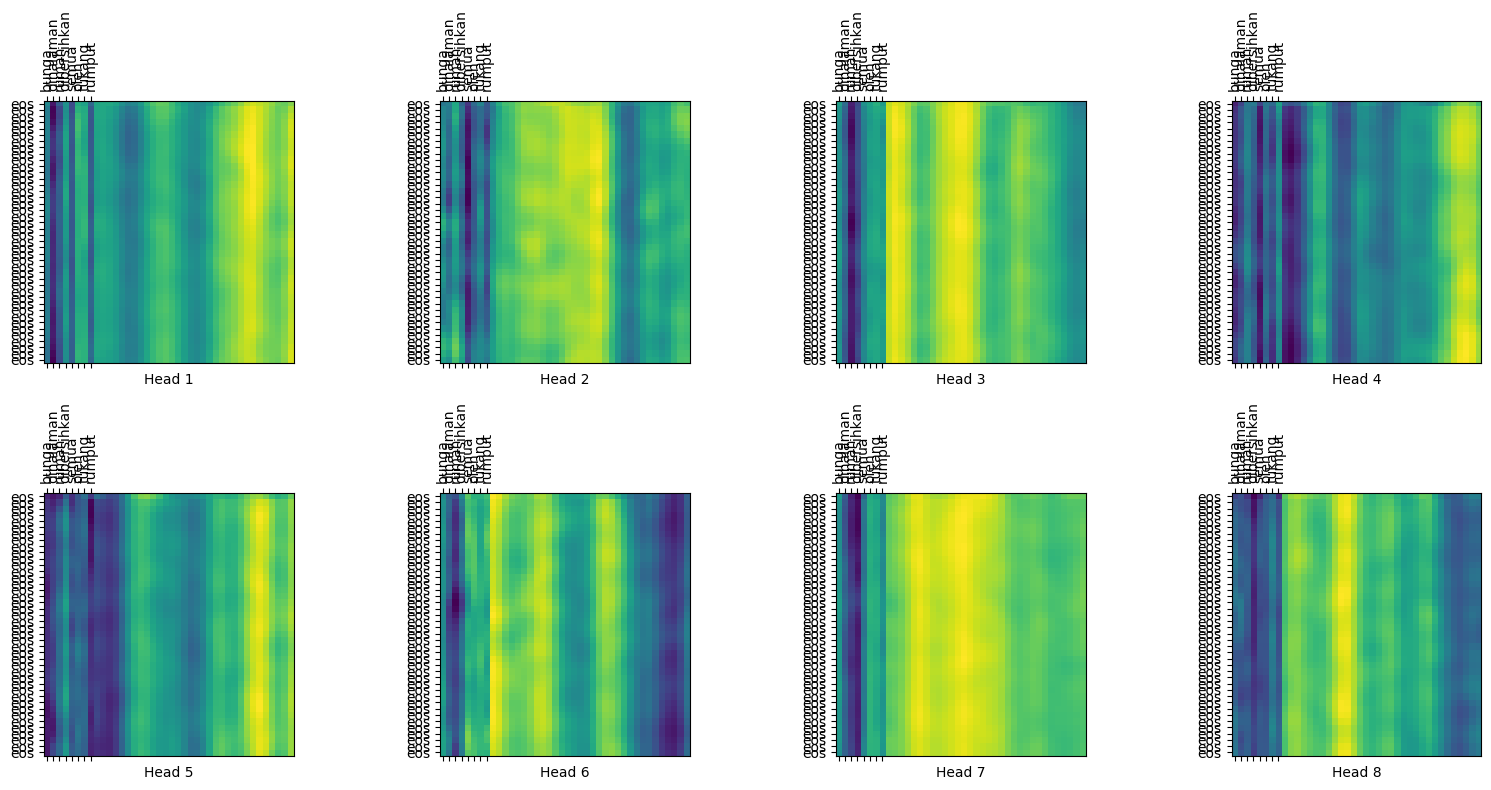

In [51]:
# Call print_translation with the decoded text string directly
print_translation(sentence, translated_text, ground_truth)

# Call plot_attention_weights with the translated token IDs tensor and attention weights
plot_attention_weights(sentence, translated_tokens, attention_weights[0], source_vectorizer, target_vectorizer)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 1 ---
Input:         : Bunga dihalaman rumah dibersihkan semua oleh tukang rumput
Prediction     : eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos
Ground truth   : Bungo dilaman rumah di babat galo dekek tukang rumput


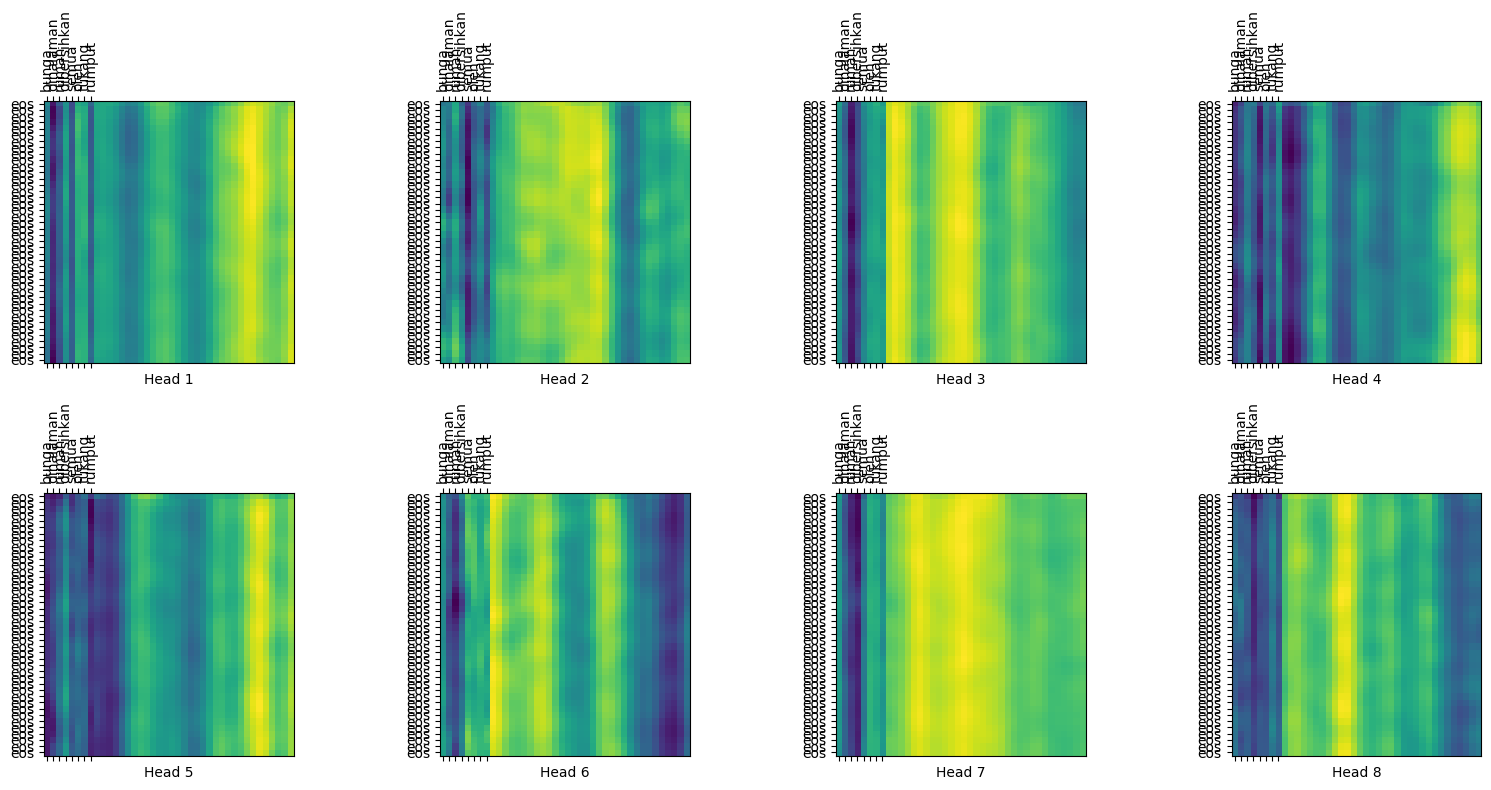

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 2 ---
Input:         : Bapak ini sangat suka dengan sayur perut sapi
Prediction     : eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos
Ground truth   : Gaek lanang iko suko nian gulai sapi babat


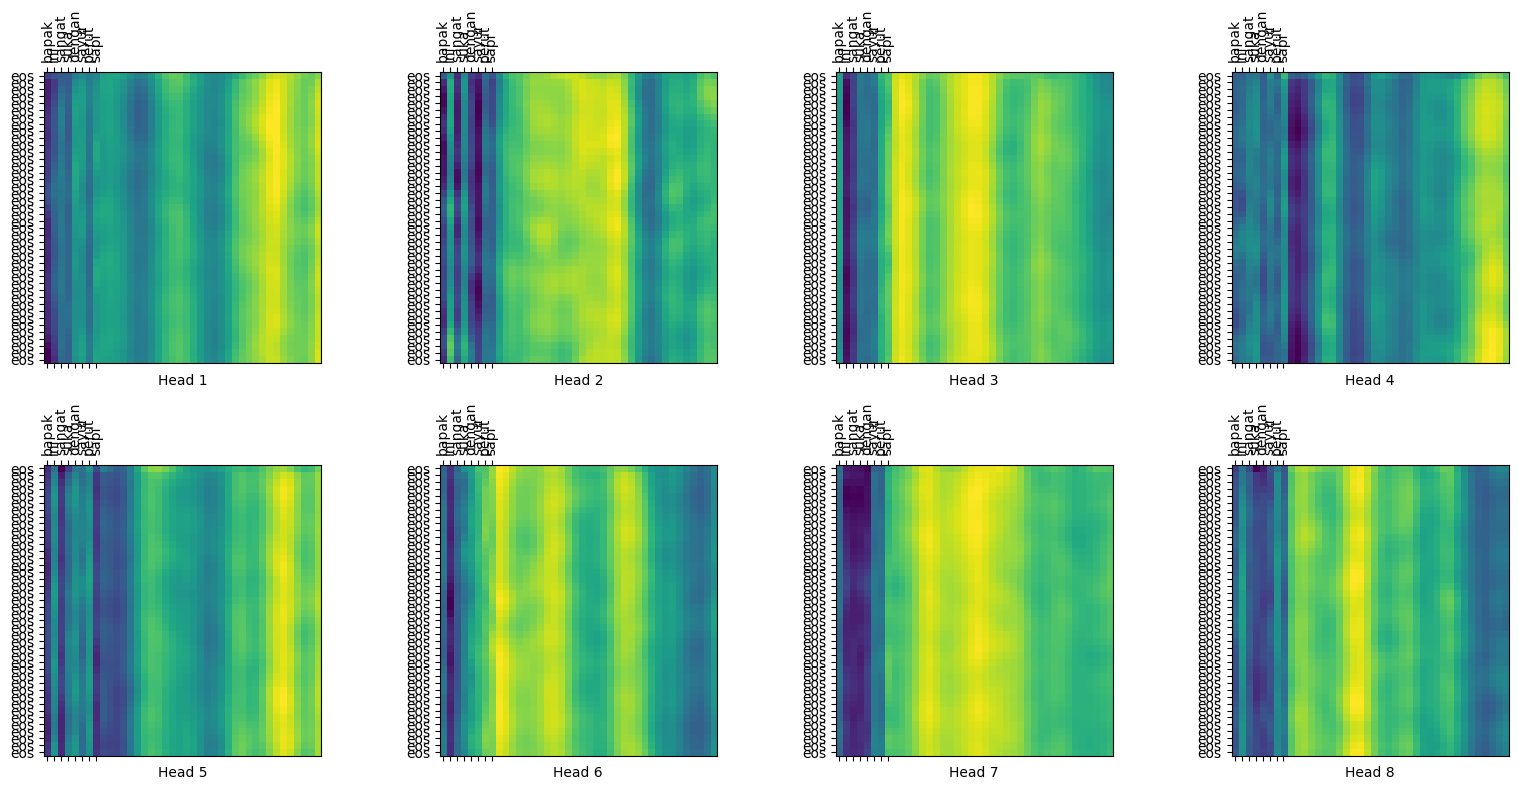

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 3 ---
Input:         : Dia menikahkan anak nya sangat besar-besaran
Prediction     : eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos
Ground truth   : Nyo nikahi anak nyo berarat-arat nian


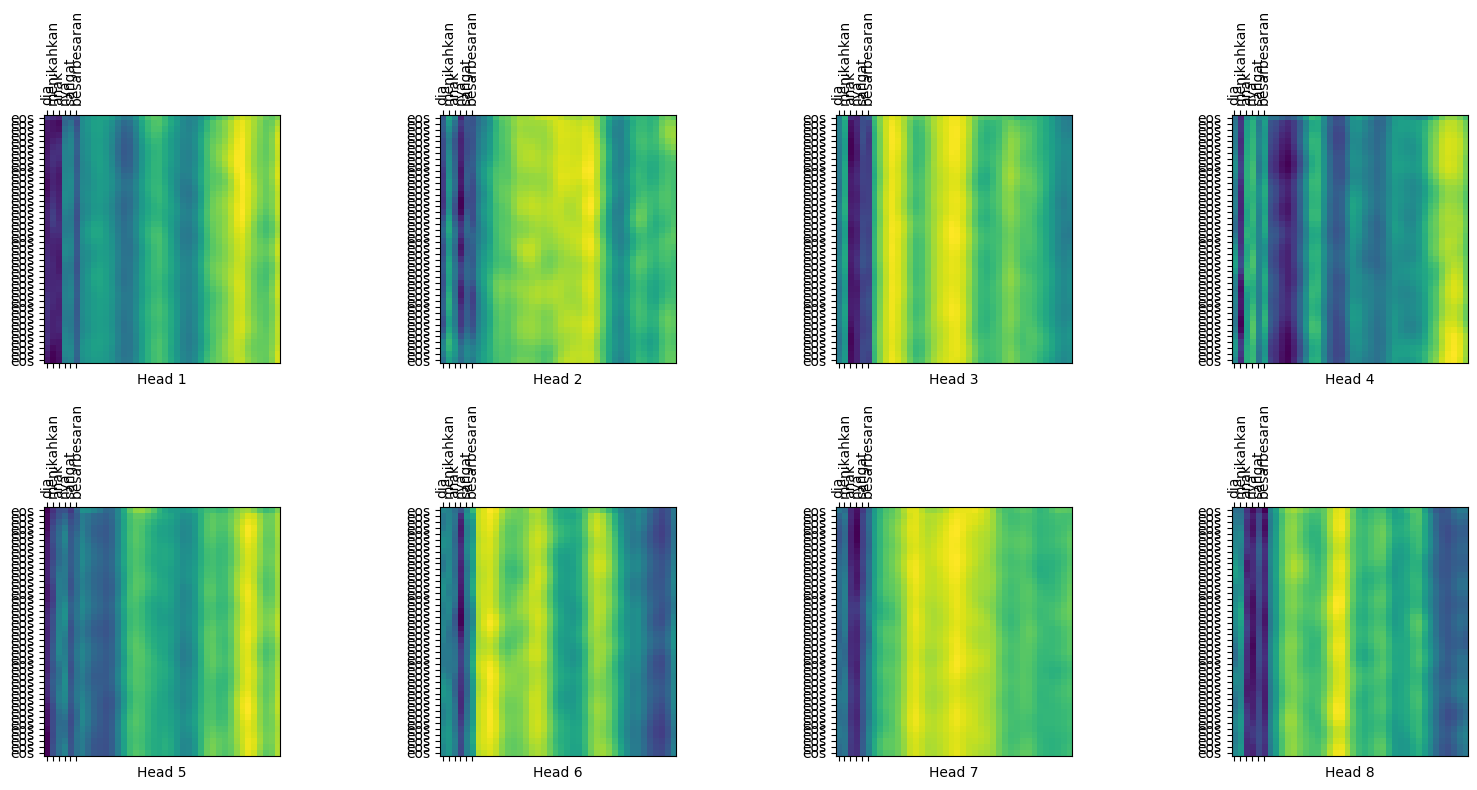

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 4 ---
Input:         : Sakitnya sekarang sudah bertambah parah
Prediction     : eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos
Ground truth   : Sakitnyo kini lah bertambah arat


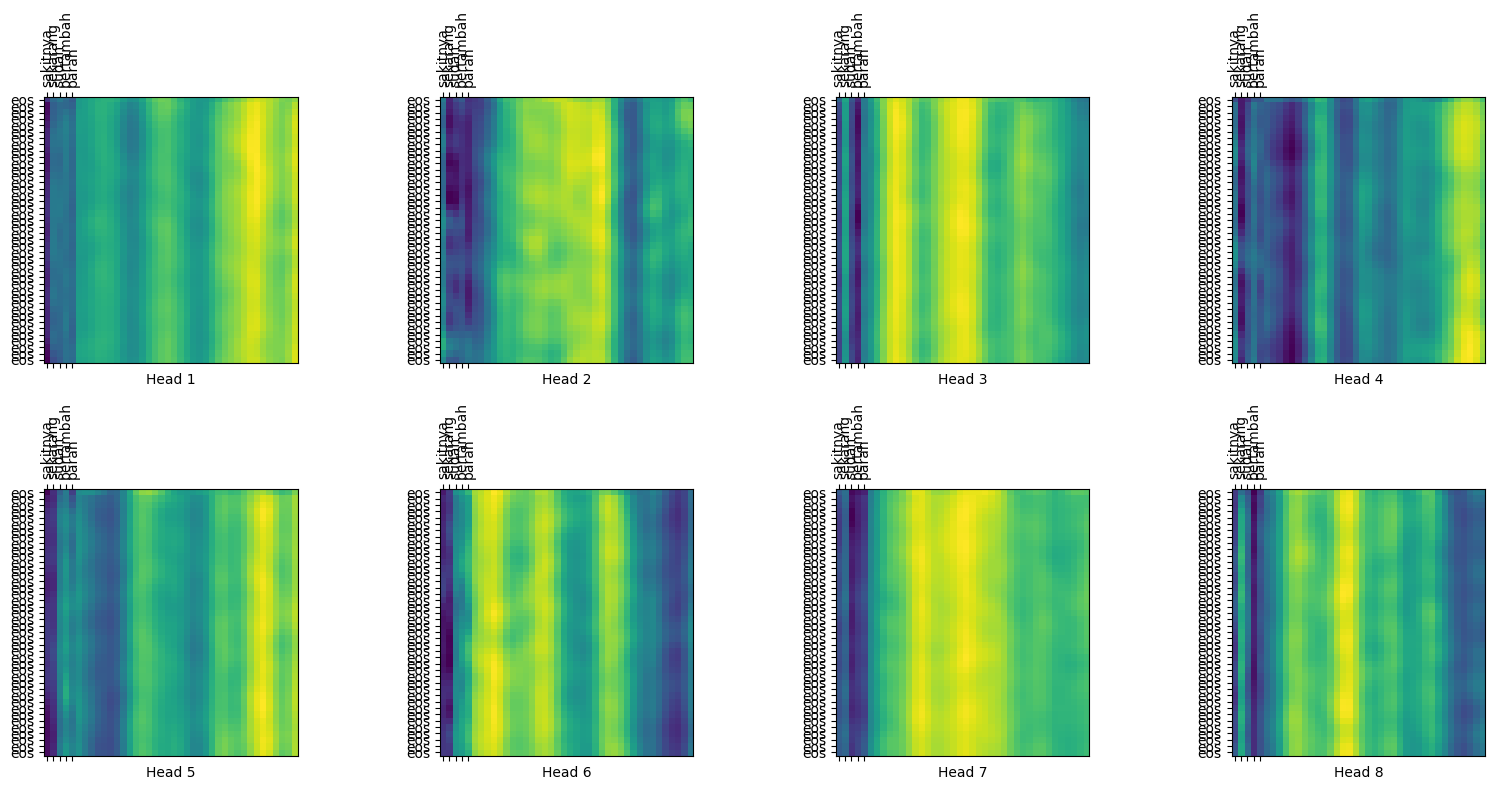

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 5 ---
Input:         : Sudah sebesar ini saya belum juga menghapal perkalian
Prediction     : eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos eos
Ground truth   : La segedang iko ambo belum jugo apal perkalian


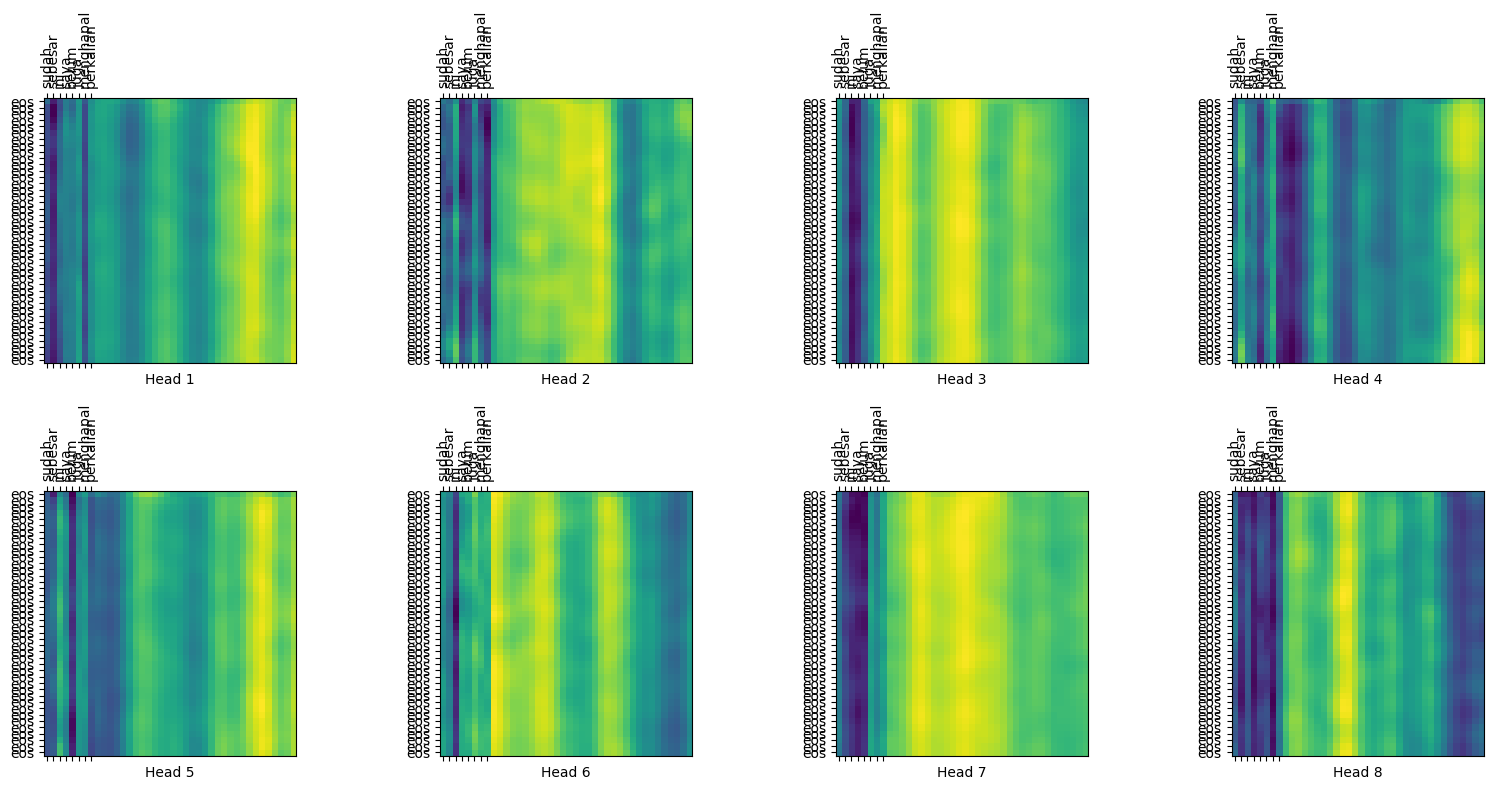

In [52]:
# In the loop for multiple examples:
num_examples_to_translate = 5 # Ubah angka ini sesuai kebutuhan Anda

for i in range(num_examples_to_translate):
    sentence = df.loc[i, 'id']
    ground_truth = df.loc[i, 'bkl']

    translated_text, translated_tokens, attention_weights = translator(
        tf.constant(sentence))

    print(f"--- Contoh Penerjemahan {i+1} ---")
    print_translation(sentence, translated_text, ground_truth)

    # Pass the necessary arguments to plot_attention_weights
    plot_attention_weights(sentence,
                           translated_tokens, # Pass the translated token IDs
                           attention_weights[0], # Pass the attention weights for the current example
                           source_vectorizer, # Pass the source vectorizer
                           target_vectorizer # Pass the target vectorizer
                           )

    print("\n") # Beri spasi antar contoh

# Evaluation with BLEU

In [53]:
def evaluate(input_sentence, transformer, source_vectorizer, target_vectorizer, max_length=40):
    # Tokenisasi input
    input_tensor = source_vectorizer([input_sentence])  # shape (1, seq_len)

    # Inisialisasi decoder dengan token <start>
    start_token = target_vectorizer([''])[0][0].numpy()  # asumsi token pertama adalah <start>
    decoder_input = tf.expand_dims([start_token], 0)  # shape (1, 1)

    output = []

    for i in range(max_length):
        predictions = transformer([input_tensor, decoder_input], training=False)
        predicted_id = tf.argmax(predictions[:, -1, :], axis=-1).numpy()[0]
        output.append(predicted_id)

        # stop jika prediksi token <end> (di sini kita anggap token padding = 0)
        if predicted_id == 0:
            break

        decoder_input = tf.concat([decoder_input, [[predicted_id]]], axis=-1)

    # Ubah output token ke string
    id_to_token = dict(enumerate(target_vectorizer.get_vocabulary()))
    decoded_tokens = [id_to_token[i] for i in output if i != 0]
    return ' '.join(decoded_tokens)


In [65]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

def evaluate_bleu(
    model,
    source_texts,
    reference_texts,
    source_vectorizer,
    target_vectorizer,
    max_samples=100,
    max_length=40
):
    hypotheses = []
    references = []
    smoother = SmoothingFunction().method4

    for src, ref in zip(source_texts[:max_samples], reference_texts[:max_samples]):
        pred = evaluate(src, model, source_vectorizer, target_vectorizer, max_length)
        hypotheses.append(word_tokenize(pred))
        references.append([word_tokenize(ref)])

    score = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return score

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [66]:
def evaluate(input_sentence, transformer, source_vectorizer, target_vectorizer, max_length=40):
    # Tokenisasi input
    input_tensor = source_vectorizer([input_sentence])  # shape (1, seq_len)

    # Inisialisasi decoder dengan token <start>
    # Find the ID of the '<sos>' token which is used as the start token in preparation
    # Use argmax to get the ID of the token that results from vectorizing ['<sos>']
    start_token = tf.argmax(target_vectorizer(['<sos>'])[0]).numpy()
    decoder_input = tf.expand_dims([start_token], 0)  # shape (1, 1)

    output = []

    for i in range(max_length):
        # Pass inputs as a dictionary
        predictions = transformer({'encoder_input': input_tensor, 'decoder_input': decoder_input}, training=False)
        predicted_id = tf.argmax(predictions[:, -1, :], axis=-1).numpy()[0]
        output.append(predicted_id)

        # stop jika prediksi token <end>
        # Find the ID of the '<eos>' token
        end_token = tf.argmax(target_vectorizer(['<eos>'])[0]).numpy()
        if predicted_id == end_token:
            break

        decoder_input = tf.concat([decoder_input, [[predicted_id]]], axis=-1)

    # Ubah output token ke string
    id_to_token = dict(enumerate(target_vectorizer.get_vocabulary()))
    # Exclude the padding token (usually 0), and start/end tokens from the output string
    decoded_tokens = [id_to_token[i] for i in output if i != 0 and i != start_token and i != end_token]
    return ' '.join(decoded_tokens)

In [67]:
# Contoh penggunaan

bleu = evaluate_bleu(
    model=transformer,
    source_texts=val_src,
    reference_texts=val_tgt,
    source_vectorizer=source_vectorizer,
    target_vectorizer=target_vectorizer,
    max_samples=5
)

print(f"BLEU Score: {bleu:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

BLEU Score: 0.0029
